In [ ]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
from google.colab import files
files.upload()
df = pd.read_csv ("/content/Mall_Customers.csv")

Saving Mall_Customers.csv to Mall_Customers (3).csv


In [ ]:
print(df)

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [ ]:
df = df.drop(columns=['Gender','CustomerID','Age'])
print('Modified DataFrame:\n', df)

Modified DataFrame:
      Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


In [ ]:
#dados em formato DataFrame estão salvos na variável df
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
#definindo e aplicando nos dados a normalização, de modo a evitar problemas por discrepancia dimensional
ssc = StandardScaler()
X = ssc.fit_transform(df)


km = KMeans(n_clusters=5,init='k-means++', random_state=0) #definindo o modelo de clustering que iremos utilizar


labels = km.fit_predict(X) #aplicando o algoritmo nos dados normalizados


# visualização do resultado

df['legendas'] = labels.astype(str)
fig = px.scatter(df, x = 'Spending Score (1-100)', y = 'Annual Income (k$)', color='legendas')
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="white",
    width = 600
)

fig.show()

In [ ]:
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 10)

for k in K:
	# Construindo e treinando o modelo
	kmeanModel = KMeans(n_clusters=k).fit(X)
	kmeanModel.fit(X)

	distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_,
										'euclidean'), axis=1)) / X.shape[0])
	inertias.append(kmeanModel.inertia_)

	mapping1[k] = sum(np.min(cdist(X, kmeanModel.cluster_centers_,
								'euclidean'), axis=1)) / X.shape[0]
	mapping2[k] = kmeanModel.inertia_

In [ ]:
kmeanModel = KMeans(n_clusters=k).fit(X)
kmeanModel.fit(X)

KMeans(n_clusters=9)

In [ ]:
sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)) / X.shape[0]

0.37808193073239105

In [ ]:
for key, val in mapping1.items():
	print(f'{key} : {val}')

1 : 1.197935444974564
2 : 1.022006300502824
3 : 0.9345473062681542
4 : 0.6351847618045524
5 : 0.5003799838317698
6 : 0.450980799410422
7 : 0.4155534446988704
8 : 0.38468861997239046
9 : 0.35803829728502623


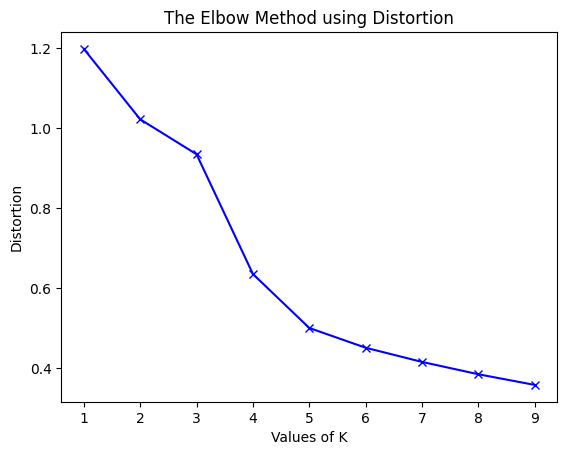

In [ ]:
plt.plot(K, distortions, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

In [ ]:
for key, val in mapping2.items():
	print(f'{key} : {val}')

1 : 399.99999999999994
2 : 271.8330524151824
3 : 224.61075262083804
4 : 108.92131661364358
5 : 65.57885579985046
6 : 57.30675447460489
7 : 46.856387684895765
8 : 37.199523875977086
9 : 32.34583777956662


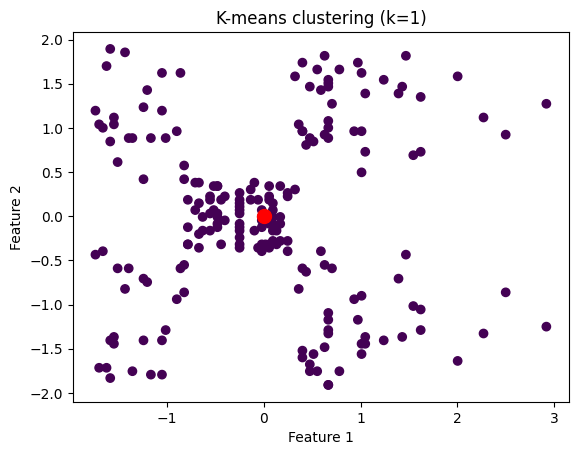

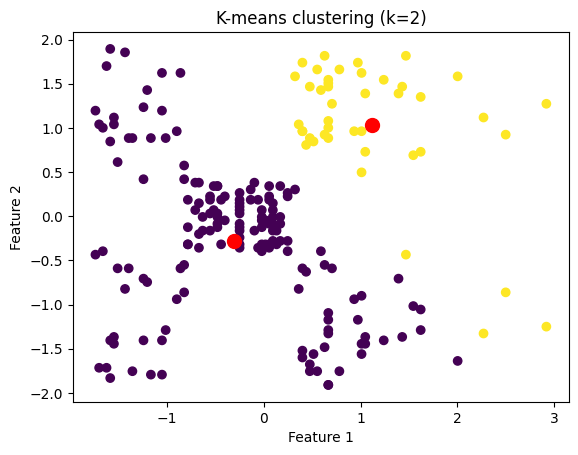

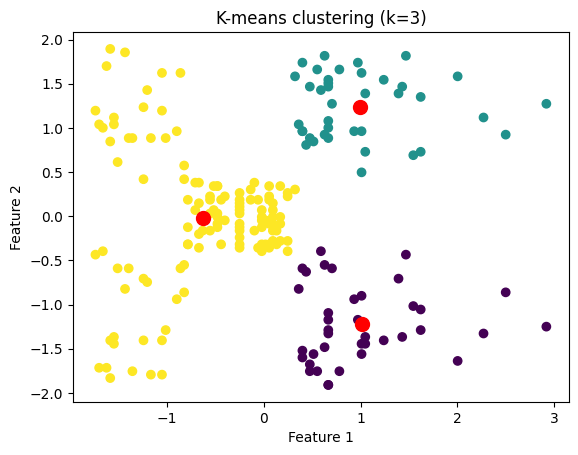

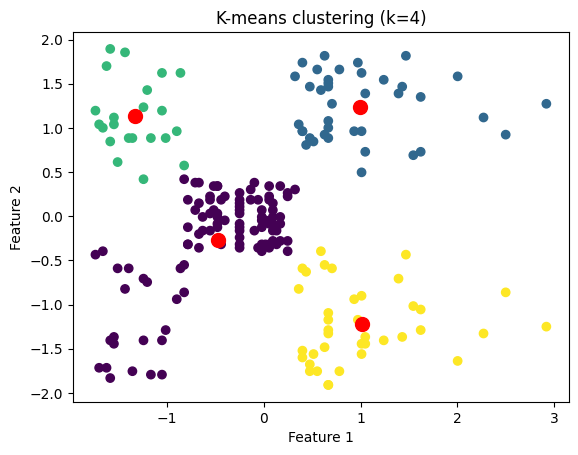

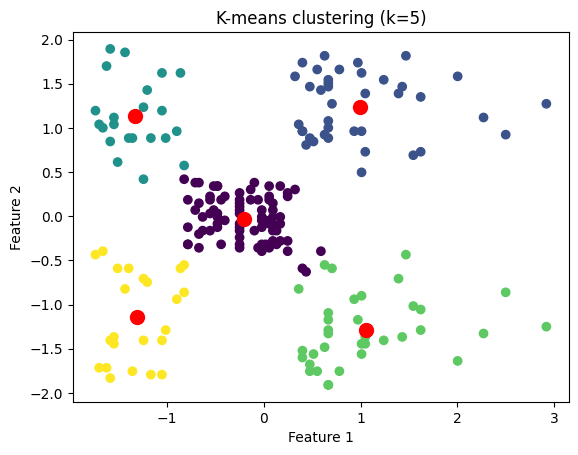

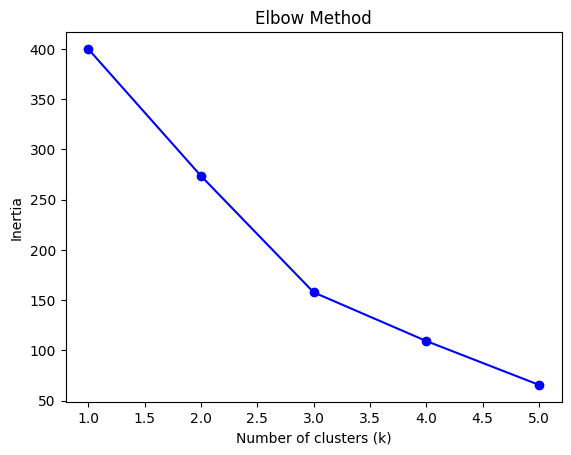

In [ ]:
# Cria um range de valores para k
k_range = range(1, 6)

# Iniciamos uma lista vazia para armazenar os valores de inércia para cada K
inertia_values = []

# Treinamos e plotamos os dados para cada valor de k
for k in k_range:
	kmeans = KMeans(n_clusters=k, \
					init='k-means++', random_state=42)
	y_kmeans = kmeans.fit_predict(X)
	inertia_values.append(kmeans.inertia_)

#Gráfico Matplotlib
	plt.scatter(X[:, 0], X[:, 1], c=y_kmeans)
	plt.scatter(kmeans.cluster_centers_[:, 0],\
				kmeans.cluster_centers_[:, 1], \
				s=100, c='red')
	plt.title('K-means clustering (k={})'.format(k))
	plt.xlabel('Feature 1')
	plt.ylabel('Feature 2')
	plt.show()

# Plota os valores de inércia para cada k
plt.plot(k_range, inertia_values, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()